<a href="https://colab.research.google.com/github/dytampn/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan2_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
!pip install scikeras
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout

from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.preprocessing import MinMaxScaler

In [6]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [7]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))


Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


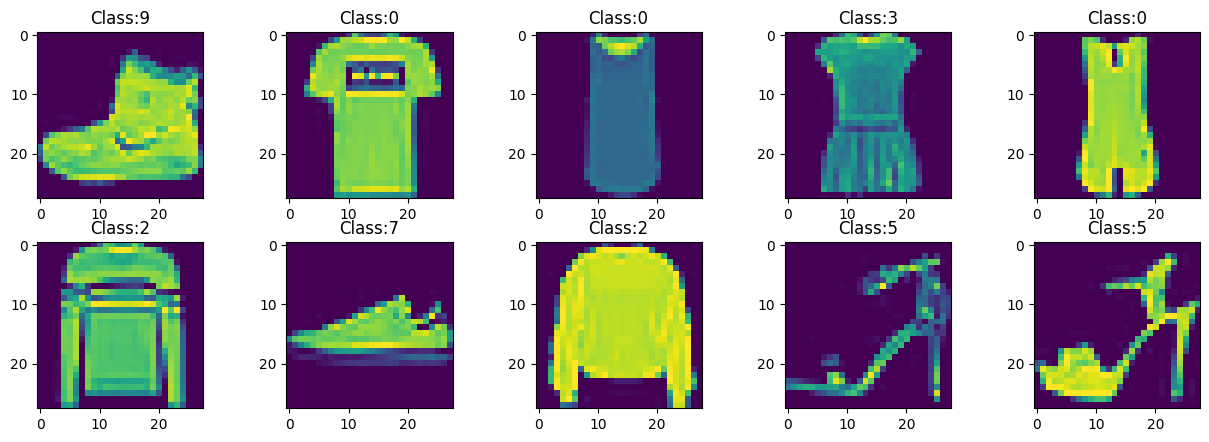

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize = (15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+ str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [9]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units = 10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_fit = fashion_model.fit(X_train, y_train, epochs=20, verbose=1, validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8233 - loss: 0.5008 - val_accuracy: 0.8513 - val_loss: 0.4139
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8667 - loss: 0.3677 - val_accuracy: 0.8723 - val_loss: 0.3751
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8805 - loss: 0.3293 - val_accuracy: 0.8777 - val_loss: 0.3356
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8870 - loss: 0.3052 - val_accuracy: 0.8773 - val_loss: 0.3408
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8930 - loss: 0.2884 - val_accuracy: 0.8832 - val_loss: 0.3224
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8992 - loss: 0.2702 - val_accuracy: 0.8798 - val_loss: 0.3350
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9030 - loss: 0.2581 - val_accuracy: 0.8833 - val_loss: 0.3337
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9076 - loss: 0.

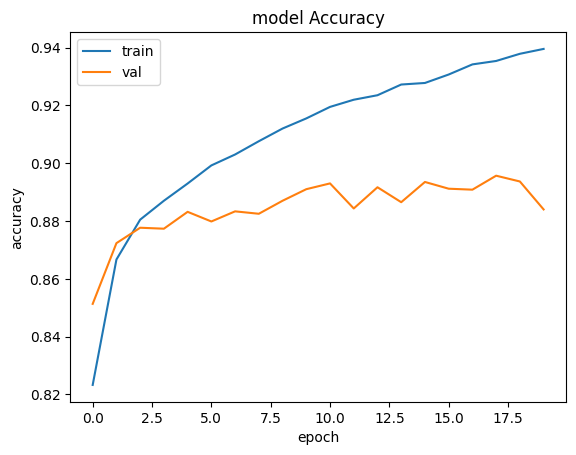

In [13]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

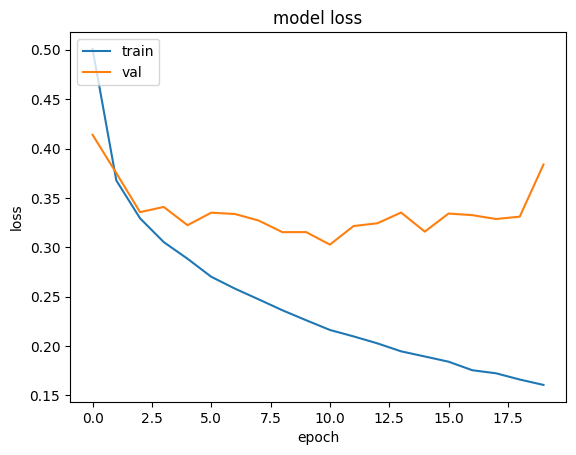

In [14]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [15]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [19]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head)
print(mnist_test.shape)

X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]
print('Number of Classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

<bound method NDFrame.head of        6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0      5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1      7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2      9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3      5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4      2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
...   .. ..  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...    ...   
19994  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19995  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19996  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19997  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
19998  5  0    0    0    0    0    0    0    0    0  ...      0      0      0  

In [21]:
model = Sequential()
model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units = 10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8719 - loss: 1.1322
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9368 - loss: 0.2350
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9421 - loss: 0.2215
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9466 - loss: 0.2036
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9533 - loss: 0.1953
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9540 - loss: 0.2171
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9566 - loss: 0.1884
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9573 - loss: 0.2025
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9610 - loss: 0.1845
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9652 - loss: 0.1882
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9674 - loss: 0.1653
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [26]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/tshirt.png', target_size=img_size, color_mode='grayscale'
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)

img_predict = model.predict(img_array)
print(img_predict)
scope = np.argmax(img_predict)
print(scope)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
2 2
(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[1.17005904e-04 1.11718373e-05 8.20300829e-06 3.90990908e-06
  4.39792686e-14 1.62129240e-07 2.82620647e-07 2.61429550e-12
  9.99859214e-01 7.22380072e-11]]
8


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
